# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from sklearn.metrics import classification_report

import os
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay
import shap

import joblib

# Exploratory Data Analysis (EDA)

In [2]:
df = pd.read_csv("../data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [3]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.shape

(1470, 35)

In [5]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [8]:
df.duplicated().sum()

0

In [9]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [10]:
df["Attrition"].value_counts()

No     1233
Yes     237
Name: Attrition, dtype: int64

In [11]:
plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

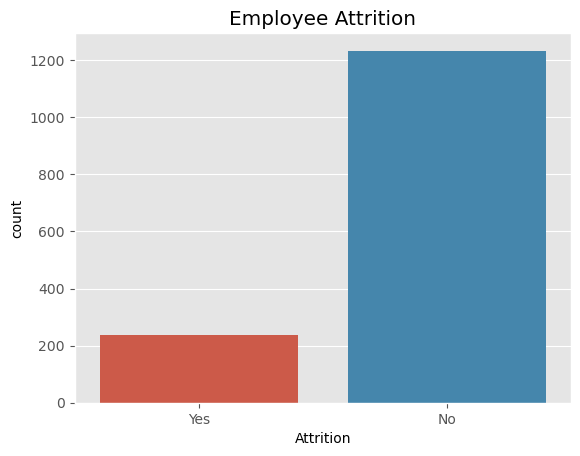

In [12]:
sns.countplot(data=df, x="Attrition")

plt.title("Employee Attrition")

plt.show()

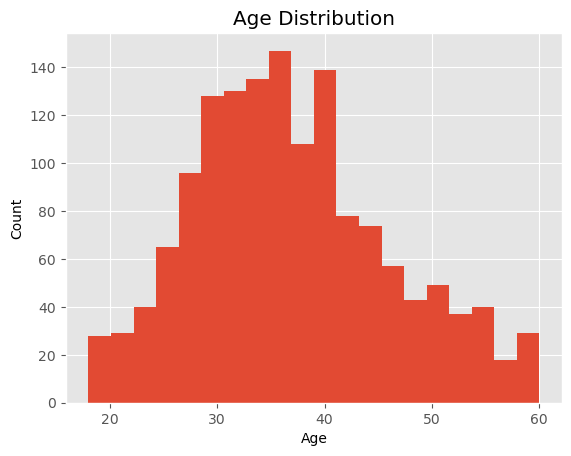

In [13]:
df["Age"].hist(bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

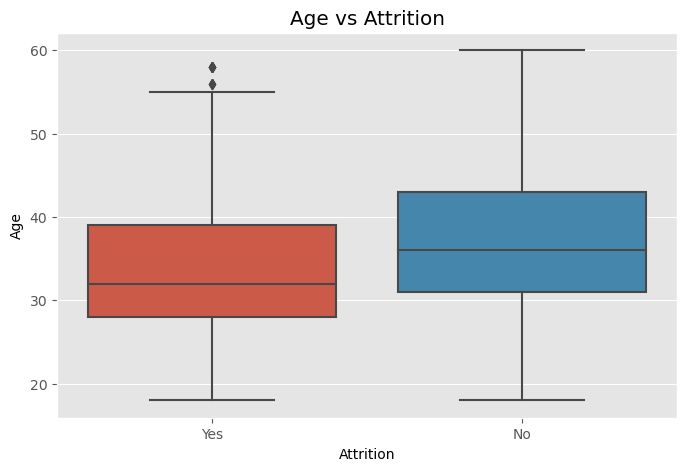

In [14]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Attrition", y="Age")

plt.title("Age vs Attrition")

plt.show()

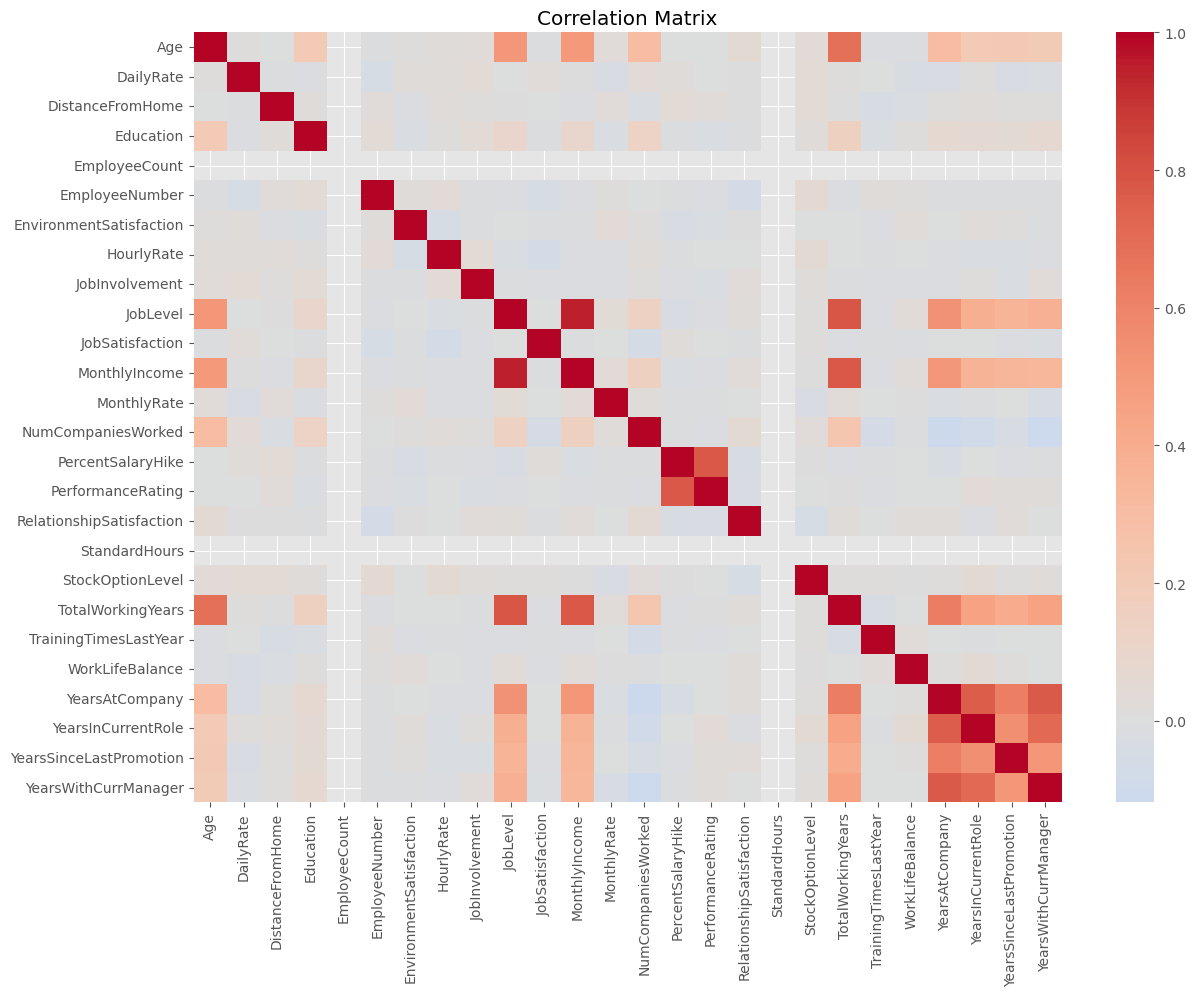

In [15]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(14, 10))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    center=0)

plt.title("Correlation Matrix")

plt.show()

In [16]:
income_by_attrition = (df.groupby("Attrition")["MonthlyIncome"].mean())

income_by_attrition

Attrition
No     6832.739659
Yes    4787.092827
Name: MonthlyIncome, dtype: float64

In [17]:
data = df.copy()

columns_to_remove = [
    "EmployeeCount",
    "StandardHours",
    "Over18",
    "EmployeeNumber"]

data.drop(columns=columns_to_remove, inplace=True)

In [18]:
data.shape

(1470, 31)

In [19]:
X = data.drop("Attrition", axis=1)

y = data["Attrition"].map({
    "Yes": 1,
    "No": 0})

In [20]:
y.value_counts()

0    1233
1     237
Name: Attrition, dtype: int64

# Train / Validation / Test split

In [21]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y)

In [22]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full)

# Data Preprocessing

In [23]:
categorical_features = X_train.select_dtypes(include="object").columns
numerical_features = X_train.select_dtypes(exclude="object").columns

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

In [24]:
pipe_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42))])

In [25]:
pipe_tree = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))])

In [26]:
pipe_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))])

In [27]:
negative = y_train.value_counts()[0]
positive = y_train.value_counts()[1]

scale_pos_weight = negative / positive

pipe_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight))])

In [28]:
param_lr = {
    "classifier__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "classifier__class_weight": [None, "balanced"],
    "classifier__solver": ["lbfgs", "liblinear"],
    "classifier__max_iter": [1000, 3000, 5000]}

In [29]:
param_tree = {
    "classifier__criterion": ["gini", "entropy"],
    "classifier__max_depth": [3, 5, 7, 10, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4, 8],
    "classifier__class_weight": [None, "balanced"]}

In [30]:
param_rf = {
    "classifier__n_estimators": [100, 200, 300, 500],
    "classifier__max_depth": [5, 10, 20, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2"],
    "classifier__class_weight": [None, "balanced"]}

In [31]:
param_xgb = {
    "classifier__n_estimators": [100, 200, 300, 500],
    "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "classifier__max_depth": [3, 4, 5, 6],
    "classifier__subsample": [0.7, 0.8, 1.0],
    "classifier__colsample_bytree": [0.7, 0.8, 1.0],
    "classifier__gamma": [0, 0.2, 0.5],
    "classifier__min_child_weight": [1, 3, 5],
    "classifier__reg_alpha": [0, 0.1, 1],
    "classifier__reg_lambda": [1, 2, 5]}

# Hyperparameter Tuning with RandomizedSearchCV

In [32]:
def tune_model(pipeline, params):

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=params,
        n_iter=25,
        scoring="f1",
        cv=5,
        random_state=42,
        n_jobs=-1
    )

    search.fit(X_train, y_train)

    return search

In [33]:
lr_search = tune_model(pipe_lr, param_lr)

tree_search = tune_model(pipe_tree, param_tree)

rf_search = tune_model(pipe_rf, param_rf)

xgb_search = tune_model(pipe_xgb, param_xgb)

# Model Evaluation on the Validation Set

In [34]:
def evaluate(name, model, X_data, y_data):

    pred = model.predict(X_data)
    probs = model.predict_proba(X_data)[:, 1]

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_data, pred),
        "Precision": precision_score(y_data, pred),
        "Recall": recall_score(y_data, pred),
        "F1": f1_score(y_data, pred),
        "ROC-AUC": roc_auc_score(y_data, probs)
    }

In [35]:
comparison = pd.DataFrame([
    evaluate("Logistic Regression", lr_search.best_estimator_, X_val, y_val),
    evaluate("Decision Tree", tree_search.best_estimator_, X_val, y_val),
    evaluate("Random Forest", rf_search.best_estimator_, X_val, y_val),
    evaluate("XGBoost", xgb_search.best_estimator_, X_val, y_val)
]).sort_values("F1", ascending=False).reset_index(drop=True)

comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.902542,0.777778,0.552632,0.646154,0.833865
1,XGBoost,0.855932,0.558824,0.500000,0.527778,0.765019
2,Random Forest,0.847458,0.531250,0.447368,0.485714,0.774322
3,Decision Tree,0.838983,0.500000,0.263158,0.344828,0.682283


# Threshold Optimization

In [36]:
def tune_threshold(model, X_data, y_data):

    probs = model.predict_proba(X_data)[:, 1]

    thresholds = np.arange(0.10, 0.91, 0.05)

    results = []

    for t in thresholds:

        pred = (probs >= t).astype(int)

        results.append({
            "Threshold": t,
            "Accuracy": accuracy_score(y_data, pred),
            "Precision": precision_score(y_data, pred, zero_division=0),
            "Recall": recall_score(y_data, pred, zero_division=0),
            "F1": f1_score(y_data, pred, zero_division=0)
        })

    results = pd.DataFrame(results)

    best = results.loc[results["F1"].idxmax()]

    return results, best

In [37]:
lr_thresholds, best_lr_threshold = tune_threshold(
    lr_search.best_estimator_,
    X_val,
    y_val
)

tree_thresholds, best_tree_threshold = tune_threshold(
    tree_search.best_estimator_,
    X_val,
    y_val
)


rf_thresholds, best_rf_threshold = tune_threshold(
    rf_search.best_estimator_,
    X_val,
    y_val
)

xgb_thresholds, best_xgb_threshold = tune_threshold(
    xgb_search.best_estimator_,
    X_val,
    y_val
)

In [38]:
threshold_summary = pd.DataFrame([
    {"Model": "Logistic Regression", **best_lr_threshold.to_dict()},
    {"Model": "Decision Tree", **best_tree_threshold.to_dict()},
    {"Model": "Random Forest", **best_rf_threshold.to_dict()},
    {"Model": "XGBoost", **best_xgb_threshold.to_dict()},
]).sort_values("F1", ascending=False)

threshold_summary

,Model,Threshold,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.45,0.906780,0.766667,0.605263,0.676471
3,XGBoost,0.60,0.881356,0.692308,0.473684,0.562500
2,Random Forest,0.45,0.813559,0.437500,0.552632,0.488372
1,Decision Tree,0.45,0.805085,0.394737,0.394737,0.394737


# Best model

In [39]:
best_model_name = threshold_summary.iloc[0]["Model"]

print("Selected model:", best_model_name)

Selected model: Logistic Regression


# Best parameters and thresholds

In [40]:
searches = {
    "Logistic Regression": lr_search,
    "Decision Tree": tree_search,
    "Random Forest": rf_search,
    "XGBoost": xgb_search
}

best_search = searches[best_model_name]

print("Best parameters:")
print(best_search.best_params_)

Best parameters:
{'classifier__solver': 'liblinear', 'classifier__max_iter': 1000, 'classifier__class_weight': None, 'classifier__C': 10}


In [41]:
thresholds = {
    "Logistic Regression": best_lr_threshold,
    "Decision Tree": best_tree_threshold,
    "Random Forest": best_rf_threshold,
    "XGBoost": best_xgb_threshold
}

final_threshold = float(
    thresholds[best_model_name]["Threshold"]
)

print("Final threshold:", final_threshold)

Final threshold: 0.45000000000000007


# Model Evaluation on the Test Set

In [42]:
def evaluate_model(name, model, X_data, y_data, threshold=0.5):

    probs = model.predict_proba(X_data)[:, 1]
    pred = (probs >= threshold).astype(int)

    return {
        "Model": name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_data, pred),
        "Precision": precision_score(
            y_data, pred, zero_division=0
        ),
        "Recall": recall_score(
            y_data, pred, zero_division=0
        ),
        "F1": f1_score(
            y_data, pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_data, probs
        )
    }

In [43]:
final_test_results = pd.DataFrame([
    evaluate_model(
        "Logistic Regression",
        lr_search.best_estimator_,
        X_test,
        y_test,
        float(best_lr_threshold["Threshold"])
    ),

    evaluate_model(
        "Decision Tree",
        tree_search.best_estimator_,
        X_test,
        y_test,
        float(best_tree_threshold["Threshold"])
    ),

    evaluate_model(
        "Random Forest",
        rf_search.best_estimator_,
        X_test,
        y_test,
        float(best_rf_threshold["Threshold"])
    ),

    evaluate_model(
        "XGBoost",
        xgb_search.best_estimator_,
        X_test,
        y_test,
        float(best_xgb_threshold["Threshold"])
    )
]).sort_values("F1", ascending=False).reset_index(drop=True)

final_test_results

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.45,0.799320,0.409091,0.574468,0.477876,0.758980
1,Logistic Regression,0.45,0.857143,0.575758,0.404255,0.475000,0.793178
2,XGBoost,0.60,0.843537,0.517241,0.319149,0.394737,0.728573
3,Decision Tree,0.45,0.795918,0.355556,0.340426,0.347826,0.727884


# Final Model Training

In [44]:
final_model = best_search.best_estimator_

final_model.fit(
    X_train_full,
    y_train_full)

print("Final model retrained successfully.")

Final model retrained successfully.


# Final Evaluation on the Test Set

In [45]:
final_probs = final_model.predict_proba(X_test)[:, 1]

final_predictions = (
    final_probs >= final_threshold
).astype(int)

final_metrics = pd.DataFrame([{
    "Model": best_model_name,
    "Threshold": final_threshold,
    "Accuracy": accuracy_score(y_test, final_predictions),
    "Precision": precision_score(y_test, final_predictions, zero_division=0),
    "Recall": recall_score(y_test, final_predictions, zero_division=0),
    "F1": f1_score(y_test, final_predictions, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, final_probs)
}])

final_metrics

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.45,0.867347,0.633333,0.404255,0.493506,0.806013


# Classification Report

In [46]:
report = classification_report(
    y_test,
    final_predictions,
    target_names=["Stay", "Leave"],
    output_dict=True
)

report_df = pd.DataFrame(report).T
report_df

,precision,recall,f1-score,support
Stay,0.893939,0.955466,0.923679,247.000000
Leave,0.633333,0.404255,0.493506,47.000000
accuracy,0.867347,0.867347,0.867347,0.867347
macro avg,0.763636,0.679860,0.708593,294.000000
weighted avg,0.852278,0.867347,0.854910,294.000000


# Model Performance Visualizations

In [47]:
os.makedirs("../figures", exist_ok=True)

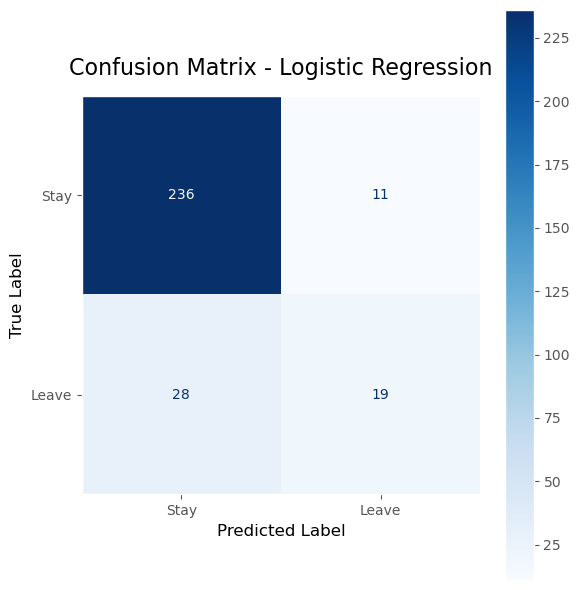

In [48]:
fig, ax = plt.subplots(figsize=(6, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_predictions,
    display_labels=["Stay", "Leave"],
    cmap="Blues",
    ax=ax
)

ax.set_title(f"Confusion Matrix - {best_model_name}", fontsize=16, pad=15)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)

ax.grid(False)

plt.tight_layout()

plt.savefig(
    "../figures/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

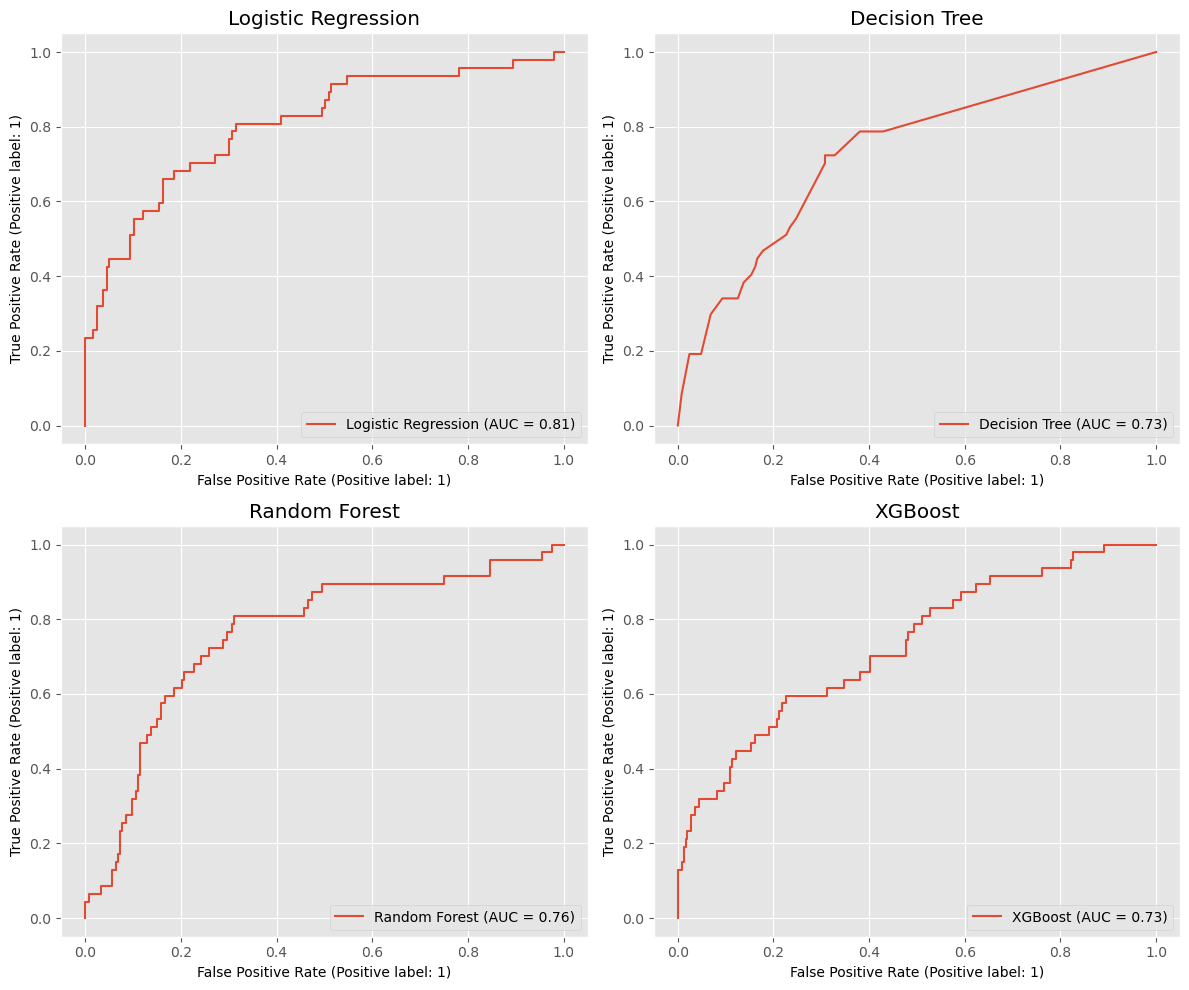

In [49]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

models = [
    ("Logistic Regression", lr_search.best_estimator_),
    ("Decision Tree", tree_search.best_estimator_),
    ("Random Forest", rf_search.best_estimator_),
    ("XGBoost", xgb_search.best_estimator_)
]

for ax, (name, model) in zip(axes.ravel(), models):

    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        ax=ax,
        name=name
    )

    ax.set_title(name)
    ax.grid(True)

plt.tight_layout()

plt.savefig(
    "../figures/roc_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

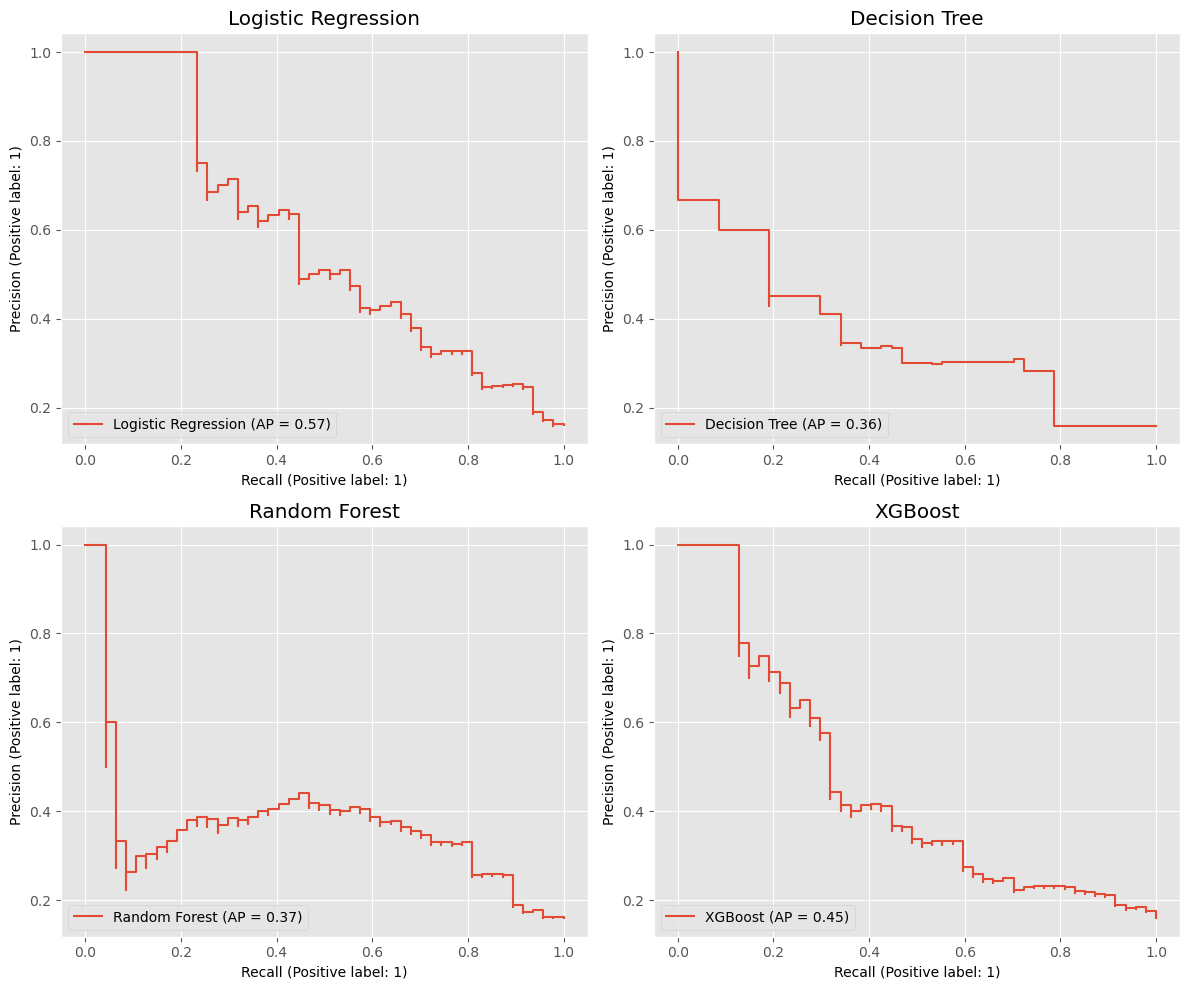

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

models = [
    ("Logistic Regression", lr_search.best_estimator_),
    ("Decision Tree", tree_search.best_estimator_),
    ("Random Forest", rf_search.best_estimator_),
    ("XGBoost", xgb_search.best_estimator_)
]

for ax, (name, model) in zip(axes.ravel(), models):

    PrecisionRecallDisplay.from_estimator(
        model,
        X_test,
        y_test,
        ax=ax,
        name=name
    )

    ax.set_title(name)
    ax.grid(True)

plt.tight_layout()

plt.savefig(
    "../figures/precision_recall_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Model Explainability with SHAP

In [51]:
best_pipeline = final_model

preprocessor = best_pipeline.named_steps["preprocessor"]

model = best_pipeline.named_steps["classifier"]

In [52]:
X_test_processed = preprocessor.transform(X_test)

In [53]:
feature_names = preprocessor.get_feature_names_out()

In [54]:
if best_model_name in [
    "Decision Tree",
    "Random Forest",
    "XGBoost"
]:

    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_test_processed)

elif best_model_name == "Logistic Regression":

    explainer = shap.LinearExplainer(
        model,
        X_test_processed
    )
    shap_values = explainer(X_test_processed)

else:
    raise ValueError(
        f"Unsupported model for SHAP: {best_model_name}"
    )

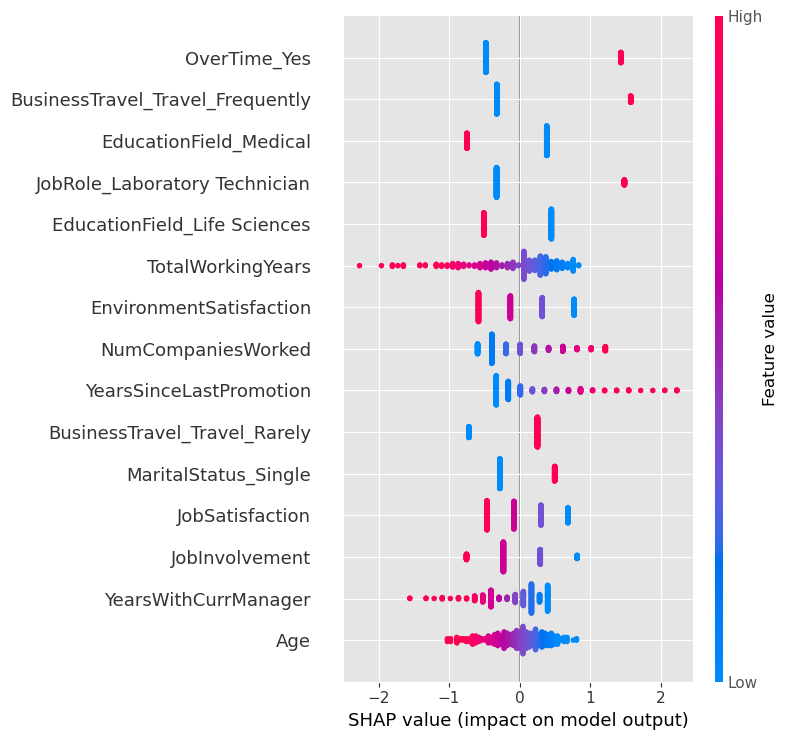

In [55]:
feature_names = [
    name.replace("categorical__", "")
        .replace("numerical__", "")
    for name in feature_names
]

shap.summary_plot(
    shap_values.values,
    X_test_processed,
    feature_names=feature_names,
    max_display=15,
    show=False
)

plt.tight_layout()

plt.savefig(
    "../figures/shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

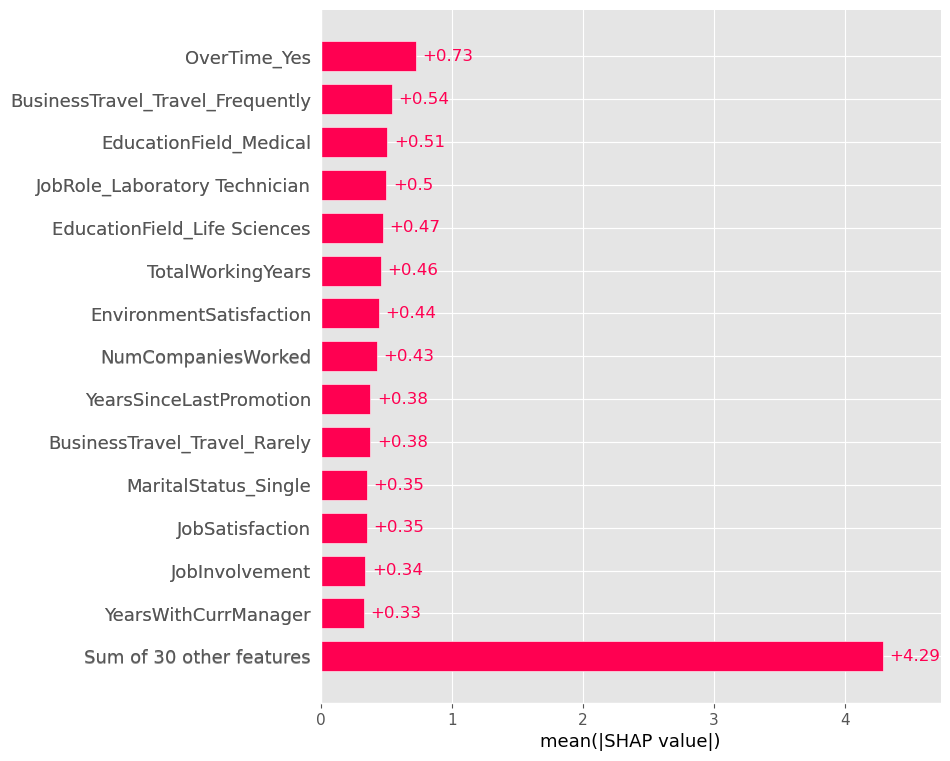

In [56]:
shap_values.feature_names = feature_names

shap.plots.bar(
    shap_values,
    max_display=15,
    show=False
)

plt.savefig(
    "../figures/shap_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [57]:
print("Prediction probability:", final_probs[0])
print("Predicted:", final_predictions[0])
print("Actual:", y_test.iloc[0])

Prediction probability: 0.07503720276223513
Predicted: 0
Actual: 0


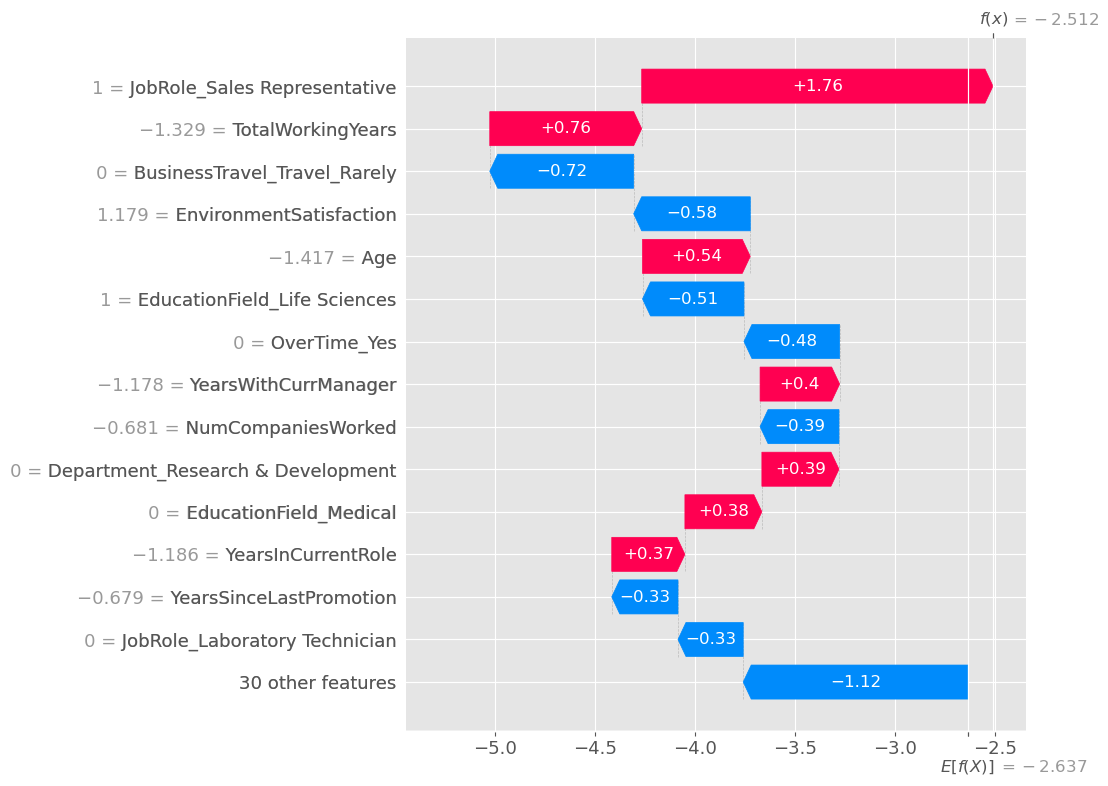

In [58]:
shap.plots.waterfall(
    shap_values[0],
    max_display=15,
    show=False
)

plt.savefig(
    "../figures/shap_waterfall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [59]:
shap.initjs()

shap.plots.force(
    shap_values[0]
)

In [60]:
mean_abs_shap = np.abs(
    shap_values.values
).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean |SHAP|": mean_abs_shap
}).sort_values(
    "Mean |SHAP|",
    ascending=False
)

print(shap_importance.head(10))

                             Feature  Mean |SHAP|
20                      OverTime_Yes     0.725668
0   BusinessTravel_Travel_Frequently     0.544305
6             EducationField_Medical     0.507994
11     JobRole_Laboratory Technician     0.499526
4       EducationField_Life Sciences     0.474564
37                 TotalWorkingYears     0.457492
25           EnvironmentSatisfaction     0.443022
32                NumCompaniesWorked     0.426748
42           YearsSinceLastPromotion     0.379953
1       BusinessTravel_Travel_Rarely     0.378193


# Save the Final Model

In [61]:
os.makedirs("../models", exist_ok=True)

artifact = {
    "model": final_model,
    "threshold": final_threshold
}

joblib.dump(
    artifact,
    "../models/employee_attrition_model.pkl"
)

print("Final model saved successfully!")
print("Model:", best_model_name)
print("Threshold:", final_threshold)

Final model saved successfully!
Model: Logistic Regression
Threshold: 0.45000000000000007
